# ============================================================
# Phase 1 - Data Cleaning for RFM Analysis
## UCI Online Retail II Dataset
### Owner: Godwin
### Output: data/cleaned/clean_retail_data.csv
# ============================================================

# 2. Import Libraries

In [171]:
"""
Goal:
Clean the raw Online Retail II transaction dataset so it can be used
for customer-level RFM Analysis.

Outputs:
1. data/cleaned/clean_retail_data.csv
2. docs/cleaning_log.md
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 3. Set Display Options

In [172]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

# 4. Define File Paths

In [173]:
RAW_PATH = "../online_retail_II.xlsx"
OUTPUT_PATH = "./cleaned/clean_retail_data.csv"
LOG_PATH = "../docs/cleaning_log.md"

# 5. Load Dataset

In [174]:
xls = pd.ExcelFile(RAW_PATH)
print(xls.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [175]:
# Load first sheet or combine all sheets if needed
df = pd.read_excel(RAW_PATH, sheet_name=0)

In [176]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# 6. Initial Audit

In [177]:
# finding the shape of the dataset
print("Shape:", df.shape)

Shape: (525461, 8)


In [178]:
# understanding the columns of the dataset
print("\nColumns:")
print(df.columns.tolist())


Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [179]:
# Getting the general information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [180]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [181]:
df.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,525461.0,525461,522533,525461.000000,525461,525461.000000,417534.000000,525461
unique,28816.0,4632,4681,NaN,NaN,NaN,NaN,40
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,675.0,3516,3549,NaN,NaN,NaN,NaN,485852
mean,NaN,NaN,NaN,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478,NaN
min,NaN,NaN,NaN,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2010-03-21 12:20:00,1.250000,13983.000000,NaN
50%,NaN,NaN,NaN,3.000000,2010-07-06 09:51:00,2.100000,15311.000000,NaN
75%,NaN,NaN,NaN,10.000000,2010-10-15 12:45:00,4.210000,16799.000000,NaN
max,NaN,NaN,NaN,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,NaN


# 7. Standardize Column Names

In [182]:
df.columns = df.columns.str.strip()
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country'], dtype='object')

# 8. Convert Data Types

In [183]:
# Ensure that all rows in the InvoiceDate are of datetime type
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
# Ensure that all rows in the Customer ID are of numeric type
df["Customer ID"] = pd.to_numeric(df["Customer ID"], errors="coerce")

# Ensure that all rows in the Quantity are of numeric type
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")

In [184]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [185]:
# Rename for consistency
df = df.rename(columns={"Customer ID": "CustomerID"})

# 9. Store Original Row Count

In [186]:
original_rows= len(df)
cleaning_summary=[]


# 10. Missing CustomerID Handling
#### 20.5% of transactions lack a customer identifier
#### Removing rows with missing CustomerID is necessary because RFM analysis is built around identifying and measuring behavior per customer.

In [187]:
before = len(df)

df = df.dropna(subset=["CustomerID"])

after = len(df)

cleaning_summary.append({
    "Step": "Drop missing CustomerID",
    "Rows Removed": before - after
})

print("Rows removed:", before - after)

Rows removed: 107927


# 11. Remove Cancelled Transactions
##### We remove cancelled transactions because they are not true purchases.

In the Online Retail II dataset, invoice numbers starting with C represent cancellations or returns. If you keep them in the data, they will distort all three RFM measures:

Frequency becomes misleading because a cancellation is not a real buying event. <br>
Monetary can be reduced or even become negative, which makes a customer look less valuable than they really are. <br>
Recency can also be distorted because a return record may appear as the latest activity even though the customer did not actually buy again.

In [188]:
before = len(df)

df = df[~df["Invoice"].astype(str).str.startswith("C", na=False)]

after = len(df)

cleaning_summary.append({
    "Step": "Remove cancelled invoices",
    "Rows Removed": before - after
})

print("Rows removed:", before - after)

Rows removed: 9839


# 12. Remove Quantity <= 0

In [189]:
before= len(df)

# keeping rows that only have quantity that is 1++

df=df[df["Quantity"]>0]

after = len(df)

cleaning_summary.append({
    "Step": "Remove Quantity <= 0",
    "Rows Removed": before - after
})

print("Rows removed:", before - after)

Rows removed: 0


# 13. Remove UnitPrice <= 0

In [190]:
before = len(df)

df = df[df["Price"] > 0]

after = len(df)

cleaning_summary.append({
    "Step": "Remove UnitPrice <= 0",
    "Rows Removed": before - after
})

print("Rows removed:", before - after)

Rows removed: 31


# 14. Remove Duplicate Rows

In [191]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

cleaning_summary.append({
    "Step": "Drop duplicates",
    "Rows Removed": before - after
})

print("Rows removed:", before - after)

Rows removed: 6748


# 15. Optional Country Filter (United Kingdom)
 Filter for Country == 'United Kingdom'. Reduces geographic noise and keeps the dataset focused.

In [192]:
before = len(df)

df = df[df["Country"] == "United Kingdom"]

after = len(df)

cleaning_summary.append({
    "Step": "Filter United Kingdom only",
    "Rows Removed": before - after
})

print("Rows removed:", before - after)

Rows removed: 36683


# 16. Clean Description Text

In [193]:
df["Description"] = df["Description"].astype(str).str.strip().str.upper()

# 17. Detect Test Products

In [194]:
test_rows = df[df["StockCode"].astype(str).str.startswith("TEST", na=False)]
print("Test rows found:", len(test_rows))
test_rows.head()

Test rows found: 10


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
27994,491725,TEST001,THIS IS A TEST PRODUCT.,10,2009-12-14 08:34:00,4.5,12346.0,United Kingdom
28251,491742,TEST001,THIS IS A TEST PRODUCT.,5,2009-12-14 11:00:00,4.5,12346.0,United Kingdom
28254,491744,TEST001,THIS IS A TEST PRODUCT.,5,2009-12-14 11:02:00,4.5,12346.0,United Kingdom
39398,492718,TEST001,THIS IS A TEST PRODUCT.,5,2009-12-18 10:47:00,4.5,12346.0,United Kingdom
39411,492722,TEST002,THIS IS A TEST PRODUCT.,1,2009-12-18 10:55:00,1.0,12346.0,United Kingdom


In [195]:
# Removing Test rows

df = df[~df["StockCode"].astype(str).str.startswith("TEST", na=False)]

# 18. Create Revenue Column

In [196]:
df["TotalSum"] = df["Quantity"] * df["Price"]

# 19. Outlier Detection

In [197]:
qty_cutoff = df["Quantity"].quantile(0.99)
price_cutoff = df["Price"].quantile(0.99)

print("99th percentile Quantity:", qty_cutoff)
print("99th percentile Price:", price_cutoff)

99th percentile Quantity: 120.0
99th percentile Price: 12.75


In [198]:
outliers = df[
    (df["Quantity"] > qty_cutoff) |
    (df["Price"] > price_cutoff)
]

print("Potential outliers:", len(outliers))
outliers.head()

Potential outliers: 6475


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalSum
217,489460,84598,BOYS ALPHABET IRON ON PATCHES,576,2009-12-01 10:46:00,0.21,16167.0,United Kingdom,120.96
223,489460,84568,GIRLS ALPHABET IRON ON PATCHES,288,2009-12-01 10:46:00,0.21,16167.0,United Kingdom,60.48
269,489465,20747,PICCADILLY TEA SET,4,2009-12-01 10:52:00,14.95,13767.0,United Kingdom,59.80
282,489465,84879,ASSORTED COLOUR BIRD ORNAMENT,160,2009-12-01 10:52:00,1.45,13767.0,United Kingdom,232.00
575,489523,84879,ASSORTED COLOUR BIRD ORNAMENT,800,2009-12-01 11:46:00,1.45,12931.0,United Kingdom,1160.00


# 20. Visual Check Distributions

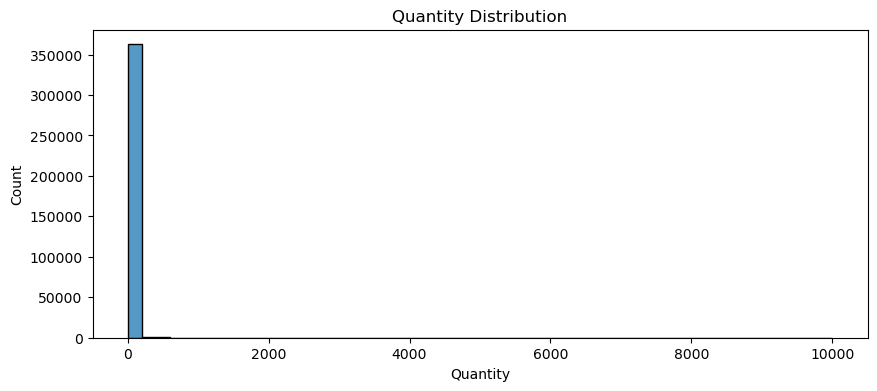

In [199]:
plt.figure(figsize=(10,4))
sns.histplot(df["Quantity"], bins=50)
plt.title("Quantity Distribution")
plt.show()

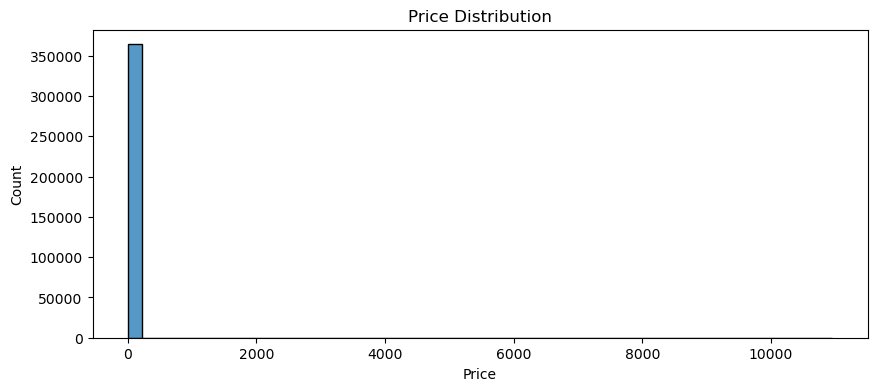

In [200]:
plt.figure(figsize=(10,4))
sns.histplot(df["Price"], bins=50)
plt.title("Price Distribution")
plt.show()

# 21. Final Validation

In [201]:
print("Final Shape:", df.shape)

Final Shape: (364223, 9)


In [202]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
CustomerID     0
Country        0
TotalSum       0
dtype: int64

In [203]:
(df["Quantity"] <= 0).sum(), (df["Price"] <= 0).sum()

(np.int64(0), np.int64(0))

In [204]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalSum
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


# 22. Save Clean Dataset

In [205]:
Path("cleaned").mkdir(parents=True, exist_ok=True)

df.to_csv(OUTPUT_PATH, index=False)

print("Saved to:", OUTPUT_PATH)

Saved to: ./cleaned/clean_retail_data.csv


# 23. Create Cleaning Summary Table

In [206]:
summary_df = pd.DataFrame(cleaning_summary)
summary_df

,Step,Rows Removed
0,Drop missing CustomerID,107927
1,Remove cancelled invoices,9839
2,Remove Quantity <= 0,0
3,Remove UnitPrice <= 0,31
4,Drop duplicates,6748
5,Filter United Kingdom only,36683


# 24. Export Cleaning Log

In [207]:
Path("../docs").mkdir(parents=True, exist_ok=True)

with open(LOG_PATH, "w", encoding="utf-8") as f:
    f.write("# Cleaning Log\n\n")
    f.write("## Original Rows: {}\n\n".format(original_rows))
    
    for row in cleaning_summary:
        f.write(f"### {row['Step']}\n")
        f.write(f"Rows Removed: {row['Rows Removed']}\n\n")
    
    f.write("## Final Rows: {}\n\n".format(len(df)))
    f.write("## Final Columns:\n")
    
    for col in df.columns:
        f.write(f"- {col}\n")

# 25. Final Summary

In [208]:
print("Original rows:", original_rows)
print("Final rows:", len(df))
print("Rows removed total:", original_rows - len(df))
print("Dataset ready for RFM scoring.")

Original rows: 525461
Final rows: 364223
Rows removed total: 161238
Dataset ready for RFM scoring.
